<a href="https://colab.research.google.com/github/GreenClothes/GreenClothes/blob/main/LPF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import math as m
import numpy as np

def sin_wave(amp, freq, time):
    return amp * np.sin(2*np.pi*freq*time)

LPF (time domain, freq. domain)

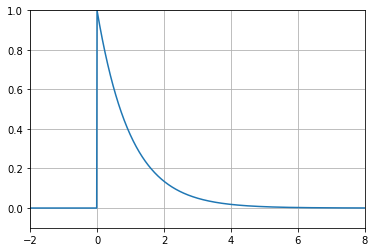

In [2]:
t=np.arange(-20,20,0.01)
y=np.heaviside(t,1)*np.exp(-t)

plt.plot(t,y)
plt.grid(True)
plt.axis([-2,8, -0.1,1])
plt.show()

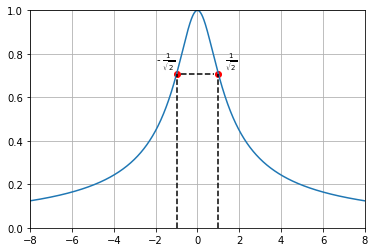

In [3]:
Y=1/np.sqrt(1+t*t)

plt.plot(t,Y)
plt.grid(True)
plt.axis([-8,8, 0,1])
plt.text(1.3, 1/np.sqrt(2)+0.05, r'$\frac{1}{\sqrt{2}}$')
plt.text(-2, 1/np.sqrt(2)+0.05, r'- $\frac{1}{\sqrt{2}}$')
plt.axhline(1/np.sqrt(2), 0.45, 0.55, color='black', linestyle='--')
plt.axvline(-1, 0, 1/np.sqrt(2), color='black', linestyle='--')
plt.axvline(1, 0, 1/np.sqrt(2), color='black', linestyle='--')
plt.scatter(1, 1/np.sqrt(2), color='red')
plt.scatter(-1, 1/np.sqrt(2), color='red')
plt.show()

In [4]:
print(1/np.sqrt(1+1))

0.7071067811865475


LPF (low freq. signal vs. high freq signal) (time domain)

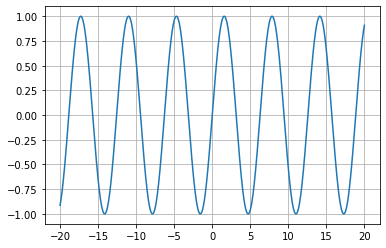

In [5]:
b=np.sin(t)

plt.plot(t,b)
plt.grid(True)
plt.show()

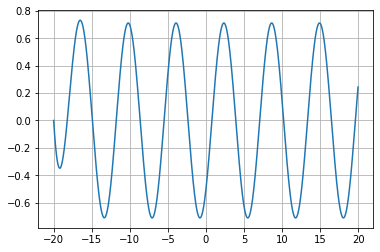

In [6]:
u=np.convolve(b,y, "same")*0.01
plt.plot(t,u)
plt.grid(True)
plt.show()

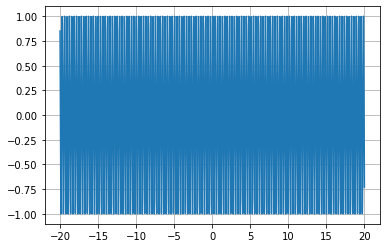

In [7]:
z=np.sin(20*t)

plt.plot(t,z)
plt.grid(True)
plt.show()

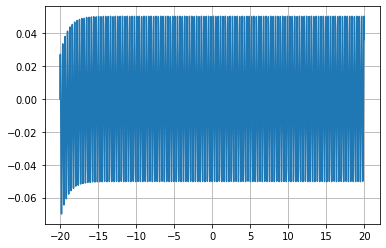

In [8]:
q=np.convolve(y,z, 'same')*0.01

plt.plot(t,q)
plt.grid(True)
plt.show()

LPF (low freq. signal vs. high freq signal) (freq. domain)

In [18]:
time = np.arange(-10, 10, 0.001)
sin1 = sin_wave(1, 1, time)
sin20 = sin_wave(1,20,time)

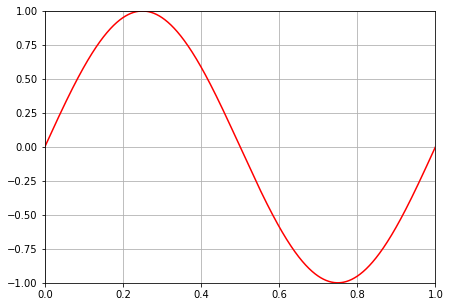

In [30]:
plt.figure(figsize=(7,5))
plt.plot(time, sin1, label=r"$\sin {20\pi} t$", color='red')
plt.axis([0,1, -1, 1])
plt.grid(); plt.show()

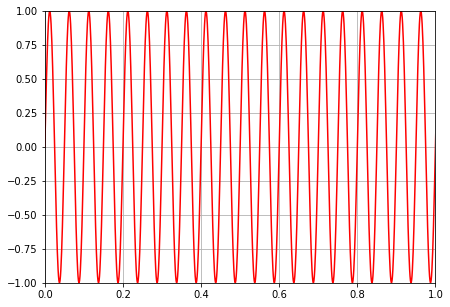

In [31]:
plt.figure(figsize=(7,5))
plt.plot(time, sin20, label=r"$\sin {20\pi} t$", color='red')
plt.axis([0,1, -1, 1])
plt.grid(); plt.show()

In [32]:
n = len(sin1) 
k = np.arange(n)
Fs = 1/0.001
T = n/Fs
freq = k/T 
freq = freq[range(int(n/2))]

In [33]:
n2 = len(sin20)
k2 = np.arange(n2)
Fs2 = 1/0.001
T2 = n2/Fs2
freq2 = k2/T2
freq2 = freq2[range(int(n2/2))]

In [34]:
Y = np.fft.fft(sin1)/n 
Y = Y[range(int(n/2))]

In [35]:
Y2 = np.fft.fft(sin20)/n2
Y2 = Y2[range(int(n2/2))]

In [36]:
m=1/np.sqrt(1+freq*freq)

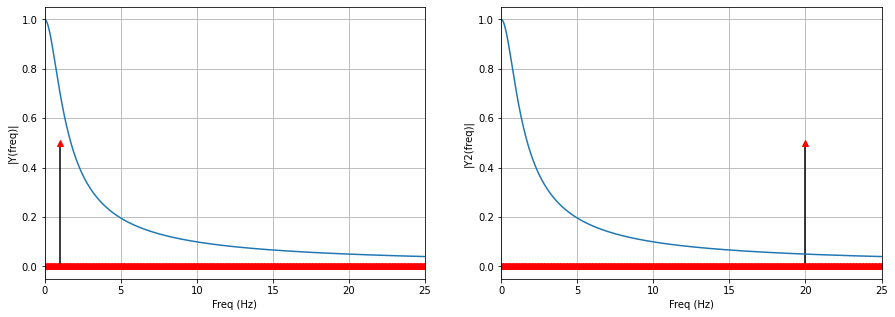

In [37]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].plot(freq, abs(Y), 'r', linestyle=' ', marker='^') 
ax[0].set_xlabel('Freq (Hz)')
ax[0].set_ylabel('|Y(freq)|')
ax[0].vlines(freq, [0], abs(Y))
ax[0].set_xlim([0, 25]); ax[0].grid(True)
ax[0].plot(freq,m)
ax[1].plot(freq2, abs(Y2), 'r', linestyle=' ', marker='^') 
ax[1].set_xlabel('Freq (Hz)')
ax[1].set_ylabel('|Y2(freq)|')
ax[1].vlines(freq2, [0], abs(Y2))
ax[1].set_xlim([0, 25]); ax[1].grid(True)
ax[1].plot(freq2,m)
plt.show()